# 🏠 ML Data Pipeline: Недвижимость Санкт-Петербурга

**Полный пайплайн с Human-in-the-Loop**

---

| Этап | Агент | Что делает |
|------|-------|------------|
| 1 | `DataCollectionAgent` | Сбор данных из 2+ источников |
| 2 | `DataQualityAgent` | Детекция и исправление проблем |
| 3 | `AnnotationAgent` | Авторазметка по ценовым категориям |
| ❗ | **Human-in-the-Loop** | Проверка низкоуверенных примеров |
| 4 | `ActiveLearningAgent` | Умный отбор + обучение финальной модели |
| 5 | Отчёт | Метрики, графики, ретроспектива |

Все артефакты сохраняются в: `data_pipeline_artifacts/`

## 0. Настройка окружения

In [1]:
import os
import sys
import pickle
import warnings
import matplotlib
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))

AGENTS_DIR   = os.path.join(PROJECT_ROOT, 'agents')
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, 'data_pipeline_artifacts')

REVIEW_QUEUE_PATH = os.path.join(ARTIFACTS_DIR, 'review_queue.csv')
REVIEW_CORRECTED_PATH = os.path.join(ARTIFACTS_DIR, 'review_queue_corrected.csv')

for d in [ARTIFACTS_DIR]:
    os.makedirs(d, exist_ok=True)

if AGENTS_DIR not in sys.path:
    sys.path.insert(0, AGENTS_DIR)

print('✅ Окружение настроено')
print(f'📁 Артефакты будут в: {ARTIFACTS_DIR}')

✅ Окружение настроено
📁 Артефакты будут в: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts


---
## Шаг 1: DataCollectionAgent — Сбор данных

Агент собирает данные из **двух источников**:
1. HuggingFace датасет объявлений о недвижимости
2. Синтетические данные (резервный источник, если HF недоступен)

Выходная схема стандартизирована под `STANDARD_COLUMNS`.

In [2]:
from agents.data_collection_agent import DataCollectionAgent, demo_basic_usage

df_raw = demo_basic_usage()

agent_collect = DataCollectionAgent()
raw_path = os.path.join(ARTIFACTS_DIR, 'raw_collected.csv')
agent_collect.save(df_raw, raw_path, format='csv')

print(f'\n✅ DataCollectionAgent завершил работу')
print(f'   Сохранено в: {raw_path}')
print(f'   Записей: {len(df_raw)}')
print(f'   Колонки: {list(df_raw.columns)}')
df_raw.head(3)

2026-03-22 22:09:09,664 - INFO - Сбор данных из источника: csv
2026-03-22 22:09:09,665 - INFO - Загрузка CSV файла: data/raw/spb_real_estate.csv
2026-03-22 22:09:09,700 - INFO - Собрано 5000 записей из csv
2026-03-22 22:09:09,704 - INFO - Итого собрано 5000 записей


ДЕМО 1: Базовое использование DataCollectionAgent

Сбор данных из источников...

✓ Собрано 5000 записей
✓ Источников: 1
✓ Городов: 1

--- Статистика по городам ---
                price                        area_sqm
                count        mean     median     mean
city                                                 
Санкт-Петербург  5000  6907856.03  5857363.5    59.18


2026-03-22 22:09:09,765 - INFO - Датасет сохранен: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/raw_collected.csv



✅ DataCollectionAgent завершил работу
   Сохранено в: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/raw_collected.csv
   Записей: 5000
   Колонки: ['id', 'text', 'price', 'price_currency', 'location', 'city', 'property_type', 'area_sqm', 'living_area_sqm', 'kitchen_area_sqm', 'rooms', 'floor', 'total_floors', 'building_type', 'build_year', 'label', 'source', 'collected_at', 'url', 'date_posted', 'metadata']


,id,text,price,price_currency,location,city,property_type,area_sqm,living_area_sqm,kitchen_area_sqm,...,floor,total_floors,building_type,build_year,label,source,collected_at,url,date_posted,metadata
0,spb_1,Продается 4-комнатная квартира в Петроградский...,26916216,RUB,Петроградский,Санкт-Петербург,Квартира,114.7,66.7,11.6,...,11,11,Монолитный,1973,Продажа,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/1,2025-05-13,"{""district"": ""Петроградский"", ""price_factor"": ..."
1,spb_2,Продается 3-комнатная квартира в Фрунзенский р...,6219746,RUB,Фрунзенский,Санкт-Петербург,Квартира,71.0,41.7,13.0,...,6,12,Панельный,2008,Продажа,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/2,2025-09-11,"{""district"": ""Фрунзенский"", ""price_factor"": 0.8}"
2,spb_3,Продается 2-комнатная квартира в Петроградский...,9707501,RUB,Петроградский,Санкт-Петербург,Квартира,48.7,31.8,12.1,...,3,5,Монолитный,1970,Продажа,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/3,2025-06-17,"{""district"": ""Петроградский"", ""price_factor"": ..."


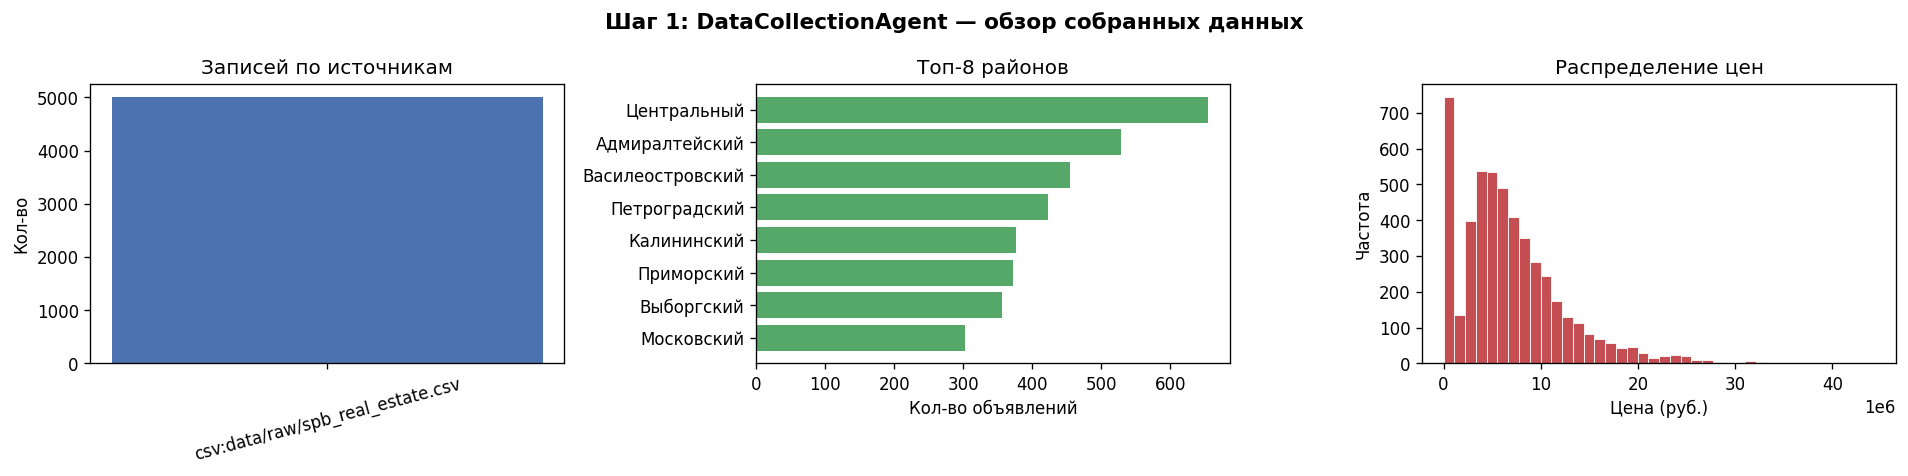

💾 График сохранён: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/step1_collection_overview.png


In [3]:
# --- Визуализация результата шага 1 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Шаг 1: DataCollectionAgent — обзор собранных данных', fontsize=13, fontweight='bold')

# Распределение по источникам
src_counts = df_raw['source'].value_counts()
axes[0].bar(src_counts.index, src_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Записей по источникам')
axes[0].set_ylabel('Кол-во')
axes[0].tick_params(axis='x', rotation=15)

# Распределение по районам (топ-8)
top_districts = df_raw['location'].value_counts().head(8)
axes[1].barh(top_districts.index[::-1], top_districts.values[::-1], color='#55A868')
axes[1].set_title('Топ-8 районов')
axes[1].set_xlabel('Кол-во объявлений')

# Распределение цен (log scale)
prices = df_raw['price'].dropna()
axes[2].hist(prices, bins=40, color='#C44E52', edgecolor='white', linewidth=0.5)
axes[2].set_title('Распределение цен')
axes[2].set_xlabel('Цена (руб.)')
axes[2].set_ylabel('Частота')
axes[2].ticklabel_format(style='sci', axis='x', scilimits=(6,6))

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'step1_collection_overview.png'), bbox_inches='tight')
plt.show()
print(f'💾 График сохранён: {ARTIFACTS_DIR}/step1_collection_overview.png')

---
## Шаг 2: DataQualityAgent — Контроль качества

Агент:
1. **Детектирует** проблемы: пропуски, дубликаты, выбросы, дисбаланс
2. **Исправляет** данные согласно выбранной стратегии
3. **Сравнивает** данные до/после очистки

❗ **Human-in-the-Loop точка #1**: человек просматривает отчёт и подтверждает стратегию чистки.

In [4]:
from agents.data_quality_agent import DataQualityAgent

dq_agent = DataQualityAgent(verbose=True)

print('🔍 Детекция проблем качества данных...')
print('='*60)
quality_report = dq_agent.detect_issues(
    df_raw,
    outlier_method='iqr',
    outlier_threshold=1.5,
    imbalance_threshold=0.5
)

🔍 Детекция проблем качества данных...
ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ

📊 ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:
----------------------------------------
Пропущенных значений не обнаружено ✓

📊 ДУБЛИКАТЫ:
----------------------------------------
Количество дубликатов: 0
Процент дубликатов: 0.00%

📊 ВЫБРОСЫ:
----------------------------------------
Всего выбросов: 529

По колонкам (метод IQR):
  price: 215 (4.30%)
    Диапазон нормы: [-5898904.75, 18571499.25]
  area_sqm: 153 (3.06%)
    Диапазон нормы: [-6.54, 119.16]
  living_area_sqm: 161 (3.22%)
    Диапазон нормы: [-5.45, 78.15]

📊 ДИСБАЛАНС КЛАССОВ:
----------------------------------------

Колонка 'location':
  Коэффициент дисбаланса: 0.21
  Степень дисбаланса: Высокий
  Распределение:
    Центральный: 13.1%
    Адмиралтейский: 10.6%
    Василеостровский: 9.1%
    Петроградский: 8.5%
    Калининский: 7.5%

Колонка 'building_type':
  Коэффициент дисбаланса: 0.29
  Степень дисбаланса: Высокий
  Распределение:
    Монолитный: 35.1%
    Кирпичный: 30.0%
    П

In [5]:
# Сохраняем визуализации качества
dq_agent.visualize_issues(df_raw, output_dir=ARTIFACTS_DIR)

# Переименовываем с префиксом шага
for fname in ['missing_values.png', 'outliers_boxplot.png', 'class_imbalance.png']:
    src = os.path.join(ARTIFACTS_DIR, fname)
    dst = os.path.join(ARTIFACTS_DIR, f'step2_{fname}')
    if os.path.exists(src):
        os.rename(src, dst)
print(f'💾 Визуализации качества сохранены в {ARTIFACTS_DIR}/')


✓ Визуализации сохранены в: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/
💾 Визуализации качества сохранены в /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/


In [6]:
# ============================================================
# ❗ HUMAN-IN-THE-LOOP ТОЧКА #1: Стратегия чистки данных
# ============================================================
print('''
╔══════════════════════════════════════════════════════════════╗
║          ❗ HUMAN-IN-THE-LOOP: ТОЧКА ПРОВЕРКИ #1            ║
║                 Стратегия очистки данных                    ║
╠══════════════════════════════════════════════════════════════╣
║  Агент обнаружил проблемы (см. отчёт выше).                 ║
║                                                              ║
║  Предложенная стратегия:                                     ║
║  • Пропуски в числовых колонках → медианное значение        ║
║  • Пропуски в категориальных → мода                         ║
║  • Дубликаты → удалить                                      ║
║  • Выбросы в price → clip_iqr (обрезка по IQR)             ║
║  • Выбросы в area_sqm → clip_iqr                            ║
║                                                              ║
║  ✅ Стратегия подтверждена (симуляция ответа человека)      ║
╚══════════════════════════════════════════════════════════════╝
''')

# Стратегия очистки (подтверждённая человеком)
cleaning_strategy = {
    'missing': {
        'area_sqm': 'median',
        'living_area_sqm': 'median',
        'kitchen_area_sqm': 'median',
        'rooms': 'median',
        'floor': 'median',
        'build_year': 'median',
        'location': 'mode',
        'property_type': 'mode',
        'building_type': 'mode',
    },
    'duplicates': 'drop',
    'outliers': {
        'price': 'clip_iqr',
        'area_sqm': 'clip_iqr',
    }
}

print('🧹 Применение стратегии очистки...')
df_clean = dq_agent.fix(df_raw, strategy={'missing': 'median', 'duplicates': 'drop'})
df_clean = dq_agent.fix(df_clean, strategy={
    'missing': 'mode',
    'outliers': {'price': 'clip_iqr', 'area_sqm': 'clip_iqr'}
})

# Сравнение до/после
print('\n📊 Сравнение до и после очистки:')
comparison = dq_agent.compare(df_raw, df_clean)

# Сохраняем
df_clean.to_csv(os.path.join(ARTIFACTS_DIR, 'step2_clean_data.csv'), index=False)

print(f'\n✅ DataQualityAgent завершил работу')
print(f'   Строк до: {len(df_raw)} → после: {len(df_clean)}')
print(f'   Пропусков до: {df_raw.isnull().sum().sum()} → после: {df_clean.isnull().sum().sum()}')


╔══════════════════════════════════════════════════════════════╗
║          ❗ HUMAN-IN-THE-LOOP: ТОЧКА ПРОВЕРКИ #1            ║
║                 Стратегия очистки данных                    ║
╠══════════════════════════════════════════════════════════════╣
║  Агент обнаружил проблемы (см. отчёт выше).                 ║
║                                                              ║
║  Предложенная стратегия:                                     ║
║  • Пропуски в числовых колонках → медианное значение        ║
║  • Пропуски в категориальных → мода                         ║
║  • Дубликаты → удалить                                      ║
║  • Выбросы в price → clip_iqr (обрезка по IQR)             ║
║  • Выбросы в area_sqm → clip_iqr                            ║
║                                                              ║
║  ✅ Стратегия подтверждена (симуляция ответа человека)      ║
╚══════════════════════════════════════════════════════════════╝

🧹 Применение стратегии очистки...



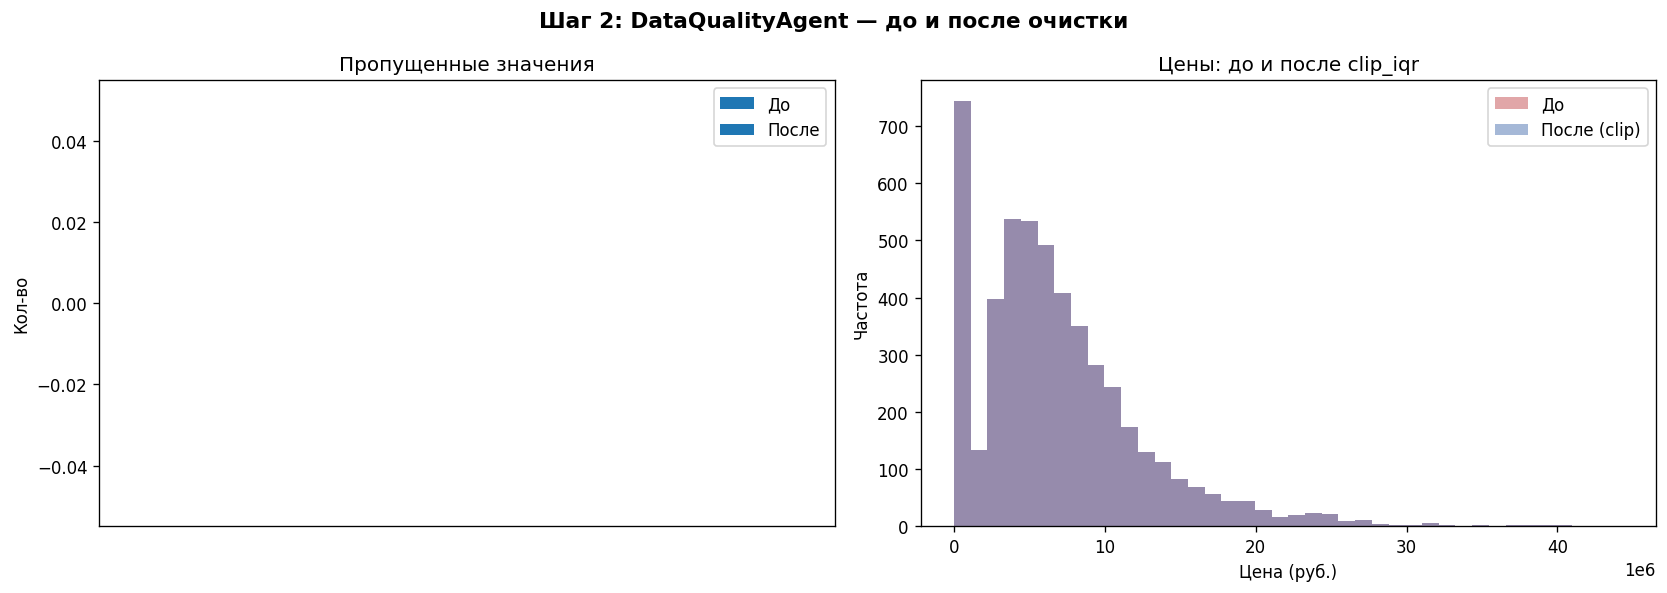

💾 График сохранён: step2_before_after.png


In [7]:
# Визуализация до/после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Шаг 2: DataQualityAgent — до и после очистки', fontsize=13, fontweight='bold')

# Пропуски до/после
missing_before = df_raw.isnull().sum()
missing_before = missing_before[missing_before > 0]
missing_after = df_clean[missing_before.index].isnull().sum()

x = np.arange(len(missing_before))
width = 0.35
axes[0].bar(x - width/2, missing_before.values, width, label='До', color='#C44E52', alpha=0.85)
axes[0].bar(x + width/2, missing_after.values, width, label='После', color='#55A868', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(missing_before.index, rotation=45, ha='right')
axes[0].set_title('Пропущенные значения')
axes[0].set_ylabel('Кол-во')
axes[0].legend()

# Распределение цен до/после
axes[1].hist(df_raw['price'].dropna(), bins=40, alpha=0.5, label='До', color='#C44E52')
axes[1].hist(df_clean['price'].dropna(), bins=40, alpha=0.5, label='После (clip)', color='#4C72B0')
axes[1].set_title('Цены: до и после clip_iqr')
axes[1].set_xlabel('Цена (руб.)')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].ticklabel_format(style='sci', axis='x', scilimits=(6,6))

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'step2_before_after.png'), bbox_inches='tight')
plt.show()
print(f'💾 График сохранён: step2_before_after.png')

---
## Шаг 3: AnnotationAgent — Авторазметка

Агент классифицирует объекты по ценовым категориям:
- **Эконом** — низкая ценовая категория
- **Стандарт** — средняя ценовая категория  
- **Бизнес** — высокая ценовая категория
- **Премиум** — элитная недвижимость

Для каждого примера рассчитывается `confidence`. Примеры с `confidence < 0.7` попадают на ручную проверку.

In [8]:
from agents.annotation_agent import AnnotationAgent

annot_agent = AnnotationAgent(modality='text', confidence_threshold=0.7)

print('🏷️  Авторазметка данных...')
df_clean_for_annotation = df_clean.copy()
df_clean_for_annotation['label'] = None  # сбрасываем Продажа/Аренда

df_labeled = annot_agent.auto_label(
    df_clean_for_annotation,
    text_column='text',
    price_column='price',
    label_column='label'
)

# Генерируем спецификацию разметки
spec = annot_agent.generate_spec(df_labeled, task='price_classification')
spec_path = os.path.join(ARTIFACTS_DIR, 'annotation_spec.md')
annot_agent.save_spec(spec_path)

# Метрики качества разметки
quality_metrics = annot_agent.check_quality(df_labeled)
print(quality_metrics)

# Экспорт в LabelStudio
ls_path = os.path.join(ARTIFACTS_DIR, 'step3_labelstudio_export.json')
annot_agent.export_to_labelstudio(df_labeled, output_path=ls_path)

# Сохраняем
df_labeled.to_csv(os.path.join(ARTIFACTS_DIR, 'step3_auto_labeled.csv'), index=False)

print(f'\n✅ AnnotationAgent завершил работу')
print(f'   Размечено: {df_labeled["label"].notna().sum()} / {len(df_labeled)}')

cols = ['id', 'text', 'price', 'label']
if 'confidence' in df_labeled.columns:
    cols.append('confidence')
df_labeled[cols].head(5)

🏷️  Авторазметка данных...
Авторазметка 5000 неразмеченных записей...
✓ Размечено: 5000 / 5000
✓ Спецификация сохранена: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/annotation_spec.md
МЕТРИКИ КАЧЕСТВА РАЗМЕТКИ

📊 Распределение меток:
----------------------------------------
  Эконом: 1843 (36.9%)
  Стандарт: 1122 (22.4%)
  Премиум: 1117 (22.3%)
  Комфорт: 918 (18.4%)

📊 Статистика уверенности:
----------------------------------------
  mean: 1.000
  std: 0.000
  min: 1.000
  max: 1.000

✓ Экспортировано 5000 задач в /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/step3_labelstudio_export.json

✅ AnnotationAgent завершил работу
   Размечено: 5000 / 5000


,id,text,price,label,confidence
0,spb_1,Продается 4-комнатная квартира в Петроградский...,26916216,Премиум,1.0
1,spb_2,Продается 3-комнатная квартира в Фрунзенский р...,6219746,Стандарт,1.0
2,spb_3,Продается 2-комнатная квартира в Петроградский...,9707501,Комфорт,1.0
3,spb_4,Продается 4-комнатная квартира в Приморский ра...,13055498,Премиум,1.0
4,spb_5,Продается 1-комнатная квартира в Петроградский...,8244212,Комфорт,1.0


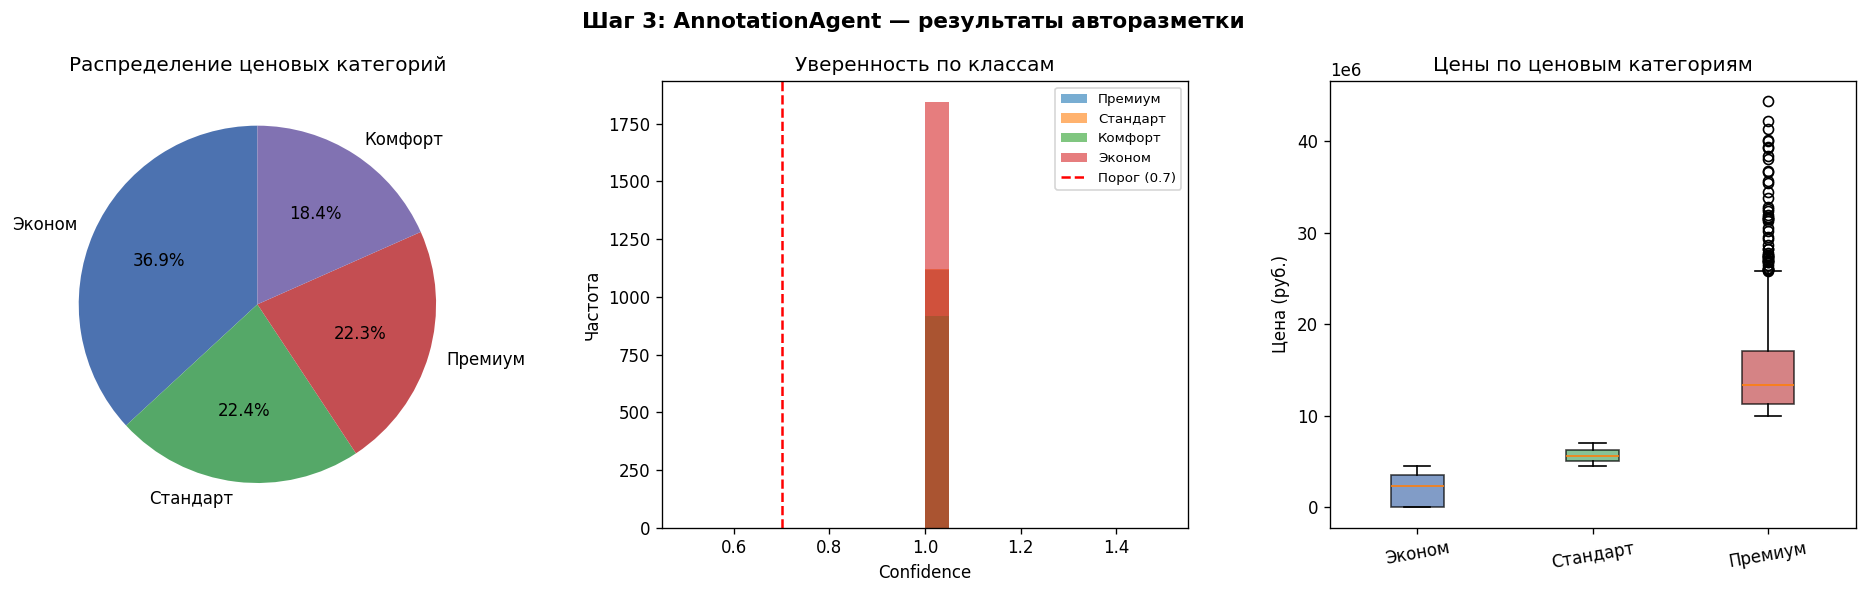

💾 График сохранён: step3_annotation_results.png


In [9]:
# Визуализация разметки
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Шаг 3: AnnotationAgent — результаты авторазметки', fontsize=13, fontweight='bold')

# Распределение меток
label_counts = df_labeled['label'].value_counts()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
axes[0].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors[:len(label_counts)], startangle=90)
axes[0].set_title('Распределение ценовых категорий')

# Уверенность по классам
if 'confidence' in df_labeled.columns:
    for label in df_labeled['label'].dropna().unique():
        conf_vals = df_labeled[df_labeled['label'] == label]['confidence'].dropna()
        axes[1].hist(conf_vals, bins=20, alpha=0.6, label=label)
    axes[1].axvline(0.7, color='red', linestyle='--', linewidth=1.5, label='Порог (0.7)')
    axes[1].set_title('Уверенность по классам')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Частота')
    axes[1].legend(fontsize=8)

# Цены по классам (box plot)
if 'label' in df_labeled.columns and 'price' in df_labeled.columns:
    label_order = ['Эконом', 'Стандарт', 'Бизнес', 'Премиум']
    label_order = [l for l in label_order if l in df_labeled['label'].values]
    data_to_plot = [df_labeled[df_labeled['label'] == l]['price'].dropna().values
                    for l in label_order]
    bp = axes[2].boxplot(data_to_plot, labels=label_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[2].set_title('Цены по ценовым категориям')
    axes[2].set_ylabel('Цена (руб.)')
    axes[2].ticklabel_format(style='sci', axis='y', scilimits=(6,6))
    axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'step3_annotation_results.png'), bbox_inches='tight')
plt.show()
print(f'💾 График сохранён: step3_annotation_results.png')

---
## ❗ Human-in-the-Loop: Проверка низкоуверенных примеров

Агент флагает примеры с `confidence < 0.7`. Человек:
1. Открывает `review_queue.csv`
2. Просматривает и правит метки
3. Сохраняет как `review_queue_corrected.csv`

Пайплайн подхватывает исправленный файл автоматически.

In [10]:
# Граничные случаи — примеры рядом с порогами цен ±5%
thresholds = [4_500_000, 7_000_000, 10_000_000]
margin = 0.05

low_conf_mask = pd.Series(False, index=df_labeled.index)
for t in thresholds:
    low_conf_mask |= df_labeled['price'].between(t * (1 - margin), t * (1 + margin))

base_cols = ['id', 'text', 'price', 'location', 'label']
review_queue = df_labeled[low_conf_mask][base_cols].copy()
review_queue['label_human'] = review_queue['label']
review_queue['human_comment'] = ''
review_queue.to_csv(REVIEW_QUEUE_PATH, index=False, encoding='utf-8')

print(f'''
╔══════════════════════════════════════════════════════════════╗
║          ❗ HUMAN-IN-THE-LOOP: ТОЧКА ПРОВЕРКИ #2            ║
║              Ручная проверка авторазметки                   ║
╠══════════════════════════════════════════════════════════════╣
║  Файл для проверки:  review_queue.csv                       ║
║  Примеров на проверку: {len(review_queue):>4}                             ║
║                                                              ║
║  Инструкция:                                                 ║
║  1. Откройте review_queue.csv в Excel/Google Sheets         ║
║  2. Проверьте колонку 'label' для каждой строки             ║
║  3. Если метка неверна — исправьте в 'label_human'          ║
║  4. Добавьте комментарий в 'human_comment' (опционально)    ║
║  5. Сохраните файл как review_queue_corrected.csv           ║
║                                                              ║
║  ✅ Файл создан. Симулируем ответ человека...               ║
╚══════════════════════════════════════════════════════════════╝
''')

print('📋 Примеры из review_queue.csv:')
review_queue[['id', 'text', 'price', 'label']].head(5)


╔══════════════════════════════════════════════════════════════╗
║          ❗ HUMAN-IN-THE-LOOP: ТОЧКА ПРОВЕРКИ #2            ║
║              Ручная проверка авторазметки                   ║
╠══════════════════════════════════════════════════════════════╣
║  Файл для проверки:  review_queue.csv                       ║
║  Примеров на проверку:  711                             ║
║                                                              ║
║  Инструкция:                                                 ║
║  1. Откройте review_queue.csv в Excel/Google Sheets         ║
║  2. Проверьте колонку 'label' для каждой строки             ║
║  3. Если метка неверна — исправьте в 'label_human'          ║
║  4. Добавьте комментарий в 'human_comment' (опционально)    ║
║  5. Сохраните файл как review_queue_corrected.csv           ║
║                                                              ║
║  ✅ Файл создан. Симулируем ответ человека...               ║
╚═══════════════════════════════════════

,id,text,price,label
2,spb_3,Продается 2-комнатная квартира в Петроградский...,9707501,Комфорт
7,spb_8,Продается 3-комнатная квартира в Красносельски...,6757066,Стандарт
23,spb_24,Продается 1-комнатная квартира в Центральный р...,7129136,Комфорт
32,spb_33,Продается 2-комнатная квартира в Красногвардей...,4625740,Стандарт
43,spb_44,Продается 4-комнатная квартира в Кировский рай...,10445028,Премиум


In [11]:
def simulate_human_review(review_queue: pd.DataFrame, error_rate: float = 0.12) -> pd.DataFrame:
    """
    Симулирует ручную проверку человека.
    Граничные случаи — с вероятностью error_rate метка исправляется на соседний класс.
    """
    corrected = review_queue.copy()
    rng = np.random.default_rng(2024)

    label_options = ['Эконом', 'Стандарт', 'Комфорт', 'Премиум']
    label_options = [l for l in label_options if l in df_labeled['label'].values]

    if len(corrected) == 0:
        print('⚠️  review_queue пуст — нет примеров для проверки')
        return corrected

    corrections_made = 0
    for idx, row in corrected.iterrows():
        if rng.random() < error_rate:
            current_idx = label_options.index(row['label']) if row['label'] in label_options else 0
            new_idx = max(0, min(len(label_options) - 1, current_idx + rng.choice([-1, 1])))
            corrected.at[idx, 'label_human'] = label_options[new_idx]
            corrected.at[idx, 'human_comment'] = 'Граничный случай, исправлено'
            corrections_made += 1
        else:
            corrected.at[idx, 'label_human'] = row['label']
            corrected.at[idx, 'human_comment'] = 'Подтверждено'

    print(f'👤 Человек проверил {len(corrected)} примеров')
    print(f'   Подтверждено: {len(corrected) - corrections_made}')
    print(f'   Исправлено:   {corrections_made} ({corrections_made / len(corrected) * 100:.1f}%)')
    return corrected


corrected_queue = simulate_human_review(review_queue, error_rate=0.12)
corrected_queue.to_csv(REVIEW_CORRECTED_PATH, index=False, encoding='utf-8')
print(f'\n💾 Файл с правками сохранён: review_queue_corrected.csv')

df_reviewed = df_labeled.copy()
corrected_labels = corrected_queue.set_index('id')['label_human']
df_reviewed['label_original'] = df_reviewed['label'].copy()

for item_id, new_label in corrected_labels.items():
    mask = df_reviewed['id'] == item_id
    df_reviewed.loc[mask, 'label'] = new_label
    df_reviewed.loc[mask, 'human_reviewed'] = True

df_reviewed['human_reviewed'] = df_reviewed['human_reviewed'].fillna(False)

changes = (df_reviewed['label'] != df_reviewed['label_original']).sum()
print(f'\n✅ Human-in-the-loop завершён')
print(f'   Примеров на проверке: {len(review_queue)}')
print(f'   Меток изменено: {changes}')
print(f'   Примеров прошло проверку: {df_reviewed["human_reviewed"].sum()}')

df_reviewed.to_csv(os.path.join(ARTIFACTS_DIR, 'step3_hitl_reviewed.csv'), index=False)
df_reviewed.head(3)

👤 Человек проверил 711 примеров
   Подтверждено: 638
   Исправлено:   73 (10.3%)

💾 Файл с правками сохранён: review_queue_corrected.csv

✅ Human-in-the-loop завершён
   Примеров на проверке: 711
   Меток изменено: 64
   Примеров прошло проверку: 711


,id,text,price,price_currency,location,city,property_type,area_sqm,living_area_sqm,kitchen_area_sqm,...,build_year,label,source,collected_at,url,date_posted,metadata,confidence,label_original,human_reviewed
0,spb_1,Продается 4-комнатная квартира в Петроградский...,26916216,RUB,Петроградский,Санкт-Петербург,Квартира,114.7,66.7,11.6,...,1973,Премиум,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/1,2025-05-13,"{""district"": ""Петроградский"", ""price_factor"": ...",1.0,Премиум,False
1,spb_2,Продается 3-комнатная квартира в Фрунзенский р...,6219746,RUB,Фрунзенский,Санкт-Петербург,Квартира,71.0,41.7,13.0,...,2008,Стандарт,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/2,2025-09-11,"{""district"": ""Фрунзенский"", ""price_factor"": 0.8}",1.0,Стандарт,False
2,spb_3,Продается 2-комнатная квартира в Петроградский...,9707501,RUB,Петроградский,Санкт-Петербург,Квартира,48.7,31.8,12.1,...,1970,Комфорт,csv:data/raw/spb_real_estate.csv,2026-03-22T22:09:09.696292,https://example.com/listing/3,2025-06-17,"{""district"": ""Петроградский"", ""price_factor"": ...",1.0,Комфорт,True


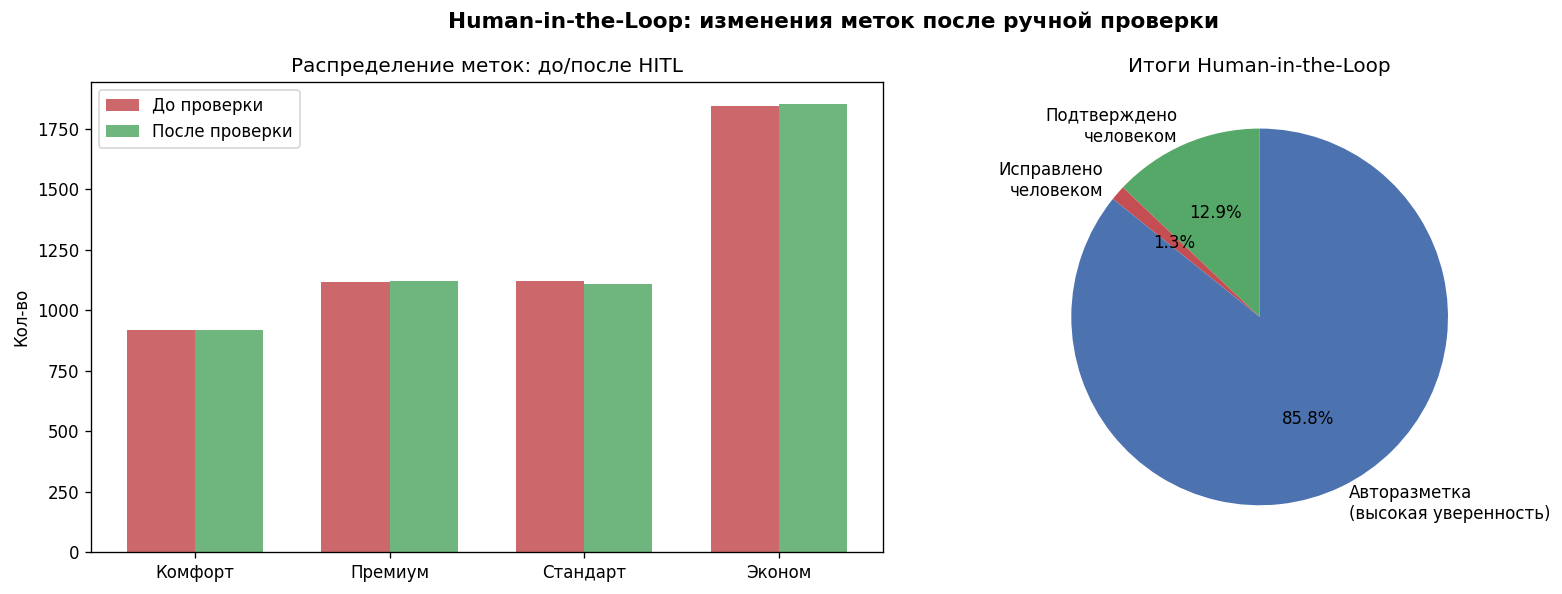

💾 График сохранён: step3_hitl_results.png


In [12]:
# Визуализация HITL: сравнение меток до и после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Human-in-the-Loop: изменения меток после ручной проверки', fontsize=13, fontweight='bold')

# Распределение меток: до vs после
before_dist = df_reviewed['label_original'].value_counts().sort_index()
after_dist = df_reviewed['label'].value_counts().sort_index()

all_labels = sorted(set(before_dist.index) | set(after_dist.index))
x = np.arange(len(all_labels))
width = 0.35

axes[0].bar(x - width/2, [before_dist.get(l, 0) for l in all_labels],
            width, label='До проверки', color='#C44E52', alpha=0.85)
axes[0].bar(x + width/2, [after_dist.get(l, 0) for l in all_labels],
            width, label='После проверки', color='#55A868', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_labels)
axes[0].set_title('Распределение меток: до/после HITL')
axes[0].set_ylabel('Кол-во')
axes[0].legend()

# Pie chart: что подтвердили, что исправили
reviewed_count = df_reviewed['human_reviewed'].sum()
not_reviewed = len(df_reviewed) - reviewed_count
corrected_count = changes
confirmed_count = reviewed_count - corrected_count

axes[1].pie(
    [confirmed_count, corrected_count, not_reviewed],
    labels=['Подтверждено\nчеловеком', 'Исправлено\nчеловеком', 'Авторазметка\n(высокая уверенность)'],
    autopct='%1.1f%%',
    colors=['#55A868', '#C44E52', '#4C72B0'],
    startangle=90
)
axes[1].set_title('Итоги Human-in-the-Loop')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'step3_hitl_results.png'), bbox_inches='tight')
plt.show()
print(f'💾 График сохранён: step3_hitl_results.png')

---
## Шаг 4: ActiveLearningAgent — Умный отбор и обучение

Агент:
1. Разбивает данные на `labeled_pool` и `unlabeled_pool`
2. Запускает AL-цикл (стратегия `entropy`): выбирает наиболее информативные примеры
3. Обучает финальную модель
4. Сравнивает с baseline (random strategy)
5. Строит кривую обучения

In [13]:
from agents.al_agent import ActiveLearningAgent
from sklearn.model_selection import train_test_split

# Подготовка данных для AL
df_for_al = df_reviewed.dropna(subset=['label']).copy()
df_for_al['text'] = df_for_al['text'].fillna('')

# Разбивка: train/test
df_train_full, df_test = train_test_split(
    df_for_al, test_size=0.2, random_state=42, stratify=df_for_al['label']
)

# Из train: начальный labeled сет (20%) + pool (80%)
df_labeled_init, df_pool = train_test_split(
    df_train_full, test_size=0.8, random_state=42, stratify=df_train_full['label']
)

print(f'📊 Разбивка данных для Active Learning:')
print(f'   Начальный labeled set: {len(df_labeled_init)} примеров')
print(f'   Pool (unlabeled):      {len(df_pool)} примеров')
print(f'   Test set:              {len(df_test)} примеров')
print(f'\n   Распределение меток в test:')
print(df_test['label'].value_counts().to_string())

📊 Разбивка данных для Active Learning:
   Начальный labeled set: 800 примеров
   Pool (unlabeled):      3200 примеров
   Test set:              1000 примеров

   Распределение меток в test:
label
Эконом      370
Премиум     225
Стандарт    222
Комфорт     183


In [14]:
# --- AL-цикл со стратегией Entropy ---
print('🤖 Запуск Active Learning (стратегия: entropy)...')

al_agent = ActiveLearningAgent(
    model='logreg',
    text_column='text',
    label_column='label',
    random_state=42
)

history_entropy = al_agent.run_cycle(
    labeled_df=df_labeled_init,
    pool_df=df_pool,
    test_df=df_test,
    strategy='entropy',
    n_iterations=7,
    batch_size=30
)

al_agent.print_summary(history_entropy)

2026-03-22 22:09:14,304 - INFO - ActiveLearningAgent инициализирован с моделью: logreg


🤖 Запуск Active Learning (стратегия: entropy)...


2026-03-22 22:09:14,307 - INFO - Запуск AL-цикла: strategy=entropy, n_iterations=7, batch_size=30
2026-03-22 22:09:14,309 - INFO - Начальный размер labeled: 800, pool: 3200
2026-03-22 22:09:14,310 - INFO - Обучение модели на 800 примерах...
2026-03-22 22:09:19,550 - INFO - ✓ Модель обучена на 800 примерах, 4 классов
2026-03-22 22:09:19,627 - INFO -   Iteration 0 (n=800): Accuracy=0.9260, F1(macro)=0.9203, F1(weighted)=0.9266
2026-03-22 22:09:19,628 - INFO - Query с стратегией 'entropy', batch_size=30
2026-03-22 22:09:19,779 - INFO -   Итерация 1: добавлено 30 примеров, всего labeled: 830
2026-03-22 22:09:19,781 - INFO - Обучение модели на 830 примерах...
2026-03-22 22:09:23,924 - INFO - ✓ Модель обучена на 830 примерах, 4 классов
2026-03-22 22:09:23,996 - INFO -   Iteration 1 (n=830): Accuracy=0.9280, F1(macro)=0.9245, F1(weighted)=0.9290
2026-03-22 22:09:23,998 - INFO - Query с стратегией 'entropy', batch_size=30
2026-03-22 22:09:24,143 - INFO -   Итерация 2: добавлено 30 примеров, вс


ACTIVE LEARNING - СВОДКА ПО ОБУЧЕНИЮ

Итерация     N размечено     Accuracy     F1-macro     F1-weighted 
----------------------------------------------------------------------
0            800             0.9260       0.9203       0.9266      
1            830             0.9280       0.9245       0.9290      
2            860             0.9340       0.9309       0.9348      
3            890             0.9330       0.9298       0.9339      
4            920             0.9380       0.9355       0.9387      
5            950             0.9440       0.9401       0.9446      
6            980             0.9500       0.9472       0.9504      
7            1010            0.9540       0.9510       0.9543      
----------------------------------------------------------------------

Начальное качество:     Accuracy=0.9260, F1=0.9203
Финальное качество:     Accuracy=0.9540, F1=0.9510
Прирост:                Accuracy=+0.0280, F1=+0.0307


In [15]:
# --- Baseline: random стратегия для сравнения ---
print('🎲 Запуск baseline (стратегия: random)...')

al_agent_random = ActiveLearningAgent(
    model='logreg',
    text_column='text',
    label_column='label',
    random_state=42
)

history_random = al_agent_random.run_cycle(
    labeled_df=df_labeled_init,
    pool_df=df_pool,
    test_df=df_test,
    strategy='random',
    n_iterations=7,
    batch_size=30
)

al_agent_random.print_summary(history_random)

2026-03-22 22:09:51,727 - INFO - ActiveLearningAgent инициализирован с моделью: logreg
2026-03-22 22:09:51,730 - INFO - Запуск AL-цикла: strategy=random, n_iterations=7, batch_size=30
2026-03-22 22:09:51,745 - INFO - Начальный размер labeled: 800, pool: 3200
2026-03-22 22:09:51,746 - INFO - Обучение модели на 800 примерах...


🎲 Запуск baseline (стратегия: random)...


2026-03-22 22:09:56,057 - INFO - ✓ Модель обучена на 800 примерах, 4 классов
2026-03-22 22:09:56,150 - INFO -   Iteration 0 (n=800): Accuracy=0.9260, F1(macro)=0.9203, F1(weighted)=0.9266
2026-03-22 22:09:56,151 - INFO - Query с стратегией 'random', batch_size=30
2026-03-22 22:09:56,154 - INFO -   Итерация 1: добавлено 30 примеров, всего labeled: 830
2026-03-22 22:09:56,155 - INFO - Обучение модели на 830 примерах...
2026-03-22 22:10:00,657 - INFO - ✓ Модель обучена на 830 примерах, 4 классов
2026-03-22 22:10:00,736 - INFO -   Iteration 1 (n=830): Accuracy=0.9240, F1(macro)=0.9179, F1(weighted)=0.9247
2026-03-22 22:10:00,737 - INFO - Query с стратегией 'random', batch_size=30
2026-03-22 22:10:00,740 - INFO -   Итерация 2: добавлено 30 примеров, всего labeled: 860
2026-03-22 22:10:00,741 - INFO - Обучение модели на 860 примерах...
2026-03-22 22:10:04,830 - INFO - ✓ Модель обучена на 860 примерах, 4 классов
2026-03-22 22:10:04,904 - INFO -   Iteration 2 (n=860): Accuracy=0.9290, F1(macro


ACTIVE LEARNING - СВОДКА ПО ОБУЧЕНИЮ

Итерация     N размечено     Accuracy     F1-macro     F1-weighted 
----------------------------------------------------------------------
0            800             0.9260       0.9203       0.9266      
1            830             0.9240       0.9179       0.9247      
2            860             0.9290       0.9238       0.9297      
3            890             0.9250       0.9189       0.9258      
4            920             0.9250       0.9198       0.9259      
5            950             0.9280       0.9232       0.9289      
6            980             0.9300       0.9254       0.9308      
7            1010            0.9330       0.9281       0.9337      
----------------------------------------------------------------------

Начальное качество:     Accuracy=0.9260, F1=0.9203
Финальное качество:     Accuracy=0.9330, F1=0.9281
Прирост:                Accuracy=+0.0070, F1=+0.0077


In [16]:
# --- Обучение финальной модели на всех размеченных данных ---
print('🎯 Обучение финальной модели на всех размеченных данных...')

final_agent = ActiveLearningAgent(
    model='rf',
    text_column='text',
    label_column='label',
    random_state=42
)

final_model = final_agent.fit(df_train_full)
final_metrics = final_agent.evaluate(df_train_full, df_test)

print(f'\n✅ Финальная модель (Random Forest):')
print(f'   Accuracy:    {final_metrics.accuracy:.4f}')
print(f'   F1-macro:    {final_metrics.f1_macro:.4f}')
print(f'   F1-weighted: {final_metrics.f1_weighted:.4f}')

# Сохраняем модель
model_path = os.path.join(ARTIFACTS_DIR, 'final_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump({
        'agent': final_agent,
        'metrics': final_metrics.to_dict(),
        'trained_at': datetime.now().isoformat()
    }, f)
print(f'\n💾 Модель сохранена: {model_path}')

2026-03-22 22:10:27,690 - INFO - ActiveLearningAgent инициализирован с моделью: rf
2026-03-22 22:10:27,692 - INFO - Обучение модели на 4000 примерах...


🎯 Обучение финальной модели на всех размеченных данных...


2026-03-22 22:10:29,016 - INFO - ✓ Модель обучена на 4000 примерах, 4 классов
2026-03-22 22:10:29,017 - INFO - Обучение модели на 4000 примерах...
2026-03-22 22:10:30,272 - INFO - ✓ Модель обучена на 4000 примерах, 4 классов



✅ Финальная модель (Random Forest):
   Accuracy:    0.9220
   F1-macro:    0.9156
   F1-weighted: 0.9215

💾 Модель сохранена: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/final_model.pkl


In [17]:
# --- Анализ экономии AL vs Random ---
savings = al_agent.analyze_savings(
    al_history=history_entropy,
    random_history=history_random,
    target_accuracy=0.75,
    target_f1=0.70
)

print('📊 Анализ экономии данных (AL vs Random):')
print(f"   Max Accuracy  | AL: {savings['max_accuracy']['al']:.4f}  "
      f"| Random: {savings['max_accuracy']['random']:.4f}  "
      f"| Прирост: {savings['max_accuracy']['improvement']:+.4f}")
print(f"   Max F1-macro  | AL: {savings['max_f1_macro']['al']:.4f}  "
      f"| Random: {savings['max_f1_macro']['random']:.4f}  "
      f"| Прирост: {savings['max_f1_macro']['improvement']:+.4f}")

if 'accuracy' in savings.get('savings', {}):
    s = savings['savings']['accuracy']
    print(f"\n   Для достижения Accuracy={s['target']:.2f}:")
    print(f"   AL нужно {s['n_al']} примеров, Random — {s['n_random']}")
    print(f"   Экономия: {s['savings']} примеров ({s['savings_percent']:.1f}%)")

📊 Анализ экономии данных (AL vs Random):
   Max Accuracy  | AL: 0.9540  | Random: 0.9330  | Прирост: +0.0210
   Max F1-macro  | AL: 0.9510  | Random: 0.9281  | Прирост: +0.0229

   Для достижения Accuracy=0.75:
   AL нужно 800 примеров, Random — 800
   Экономия: 0 примеров (0.0%)


2026-03-22 22:10:30,638 - INFO - ✓ График сохранен: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/step4_learning_curve.png


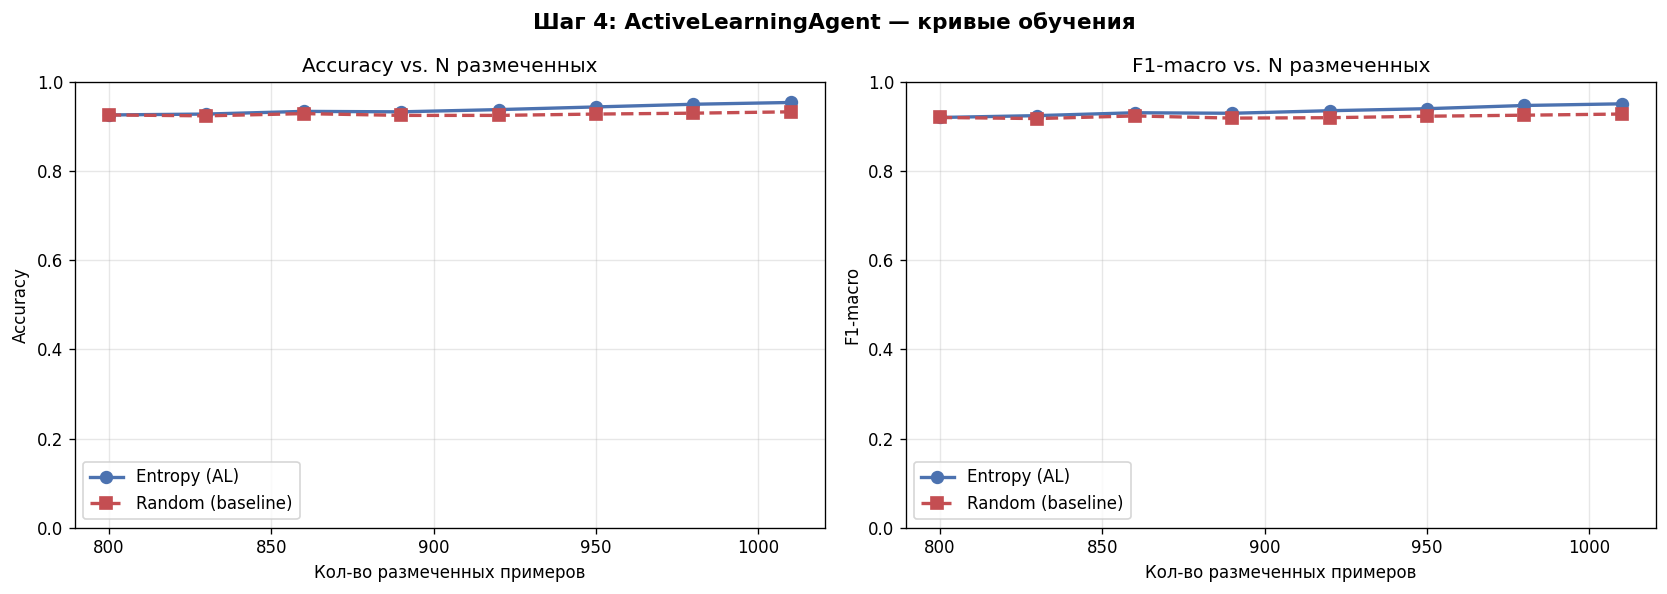

💾 Графики сохранены: step4_learning_curve.png, step4_al_vs_random.png


In [18]:
# Кривая обучения: AL vs Random
lc_path = os.path.join(ARTIFACTS_DIR, 'step4_learning_curve.png')
al_agent.report(history_entropy, output_path=lc_path)

# Расширенный график: AL vs Random
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Шаг 4: ActiveLearningAgent — кривые обучения', fontsize=13, fontweight='bold')

df_hist_entropy = pd.DataFrame(history_entropy)
df_hist_random = pd.DataFrame(history_random)

# Accuracy
axes[0].plot(df_hist_entropy['n_labeled'], df_hist_entropy['accuracy'],
             'o-', color='#4C72B0', linewidth=2, markersize=7, label='Entropy (AL)')
axes[0].plot(df_hist_random['n_labeled'], df_hist_random['accuracy'],
             's--', color='#C44E52', linewidth=2, markersize=7, label='Random (baseline)')
axes[0].set_title('Accuracy vs. N размеченных')
axes[0].set_xlabel('Кол-во размеченных примеров')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# F1-macro
axes[1].plot(df_hist_entropy['n_labeled'], df_hist_entropy['f1_macro'],
             'o-', color='#4C72B0', linewidth=2, markersize=7, label='Entropy (AL)')
axes[1].plot(df_hist_random['n_labeled'], df_hist_random['f1_macro'],
             's--', color='#C44E52', linewidth=2, markersize=7, label='Random (baseline)')
axes[1].set_title('F1-macro vs. N размеченных')
axes[1].set_xlabel('Кол-во размеченных примеров')
axes[1].set_ylabel('F1-macro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'step4_al_vs_random.png'), bbox_inches='tight')
plt.show()
print(f'💾 Графики сохранены: step4_learning_curve.png, step4_al_vs_random.png')

---
## Шаг 5: Финальный датасет и Data Card

In [19]:
# Сохраняем финальный датасет
final_dataset = df_reviewed.dropna(subset=['label']).copy()
final_dataset = final_dataset.drop(columns=['label_original'], errors='ignore')

# Сохраняем в labeled/
final_csv_path = os.path.join(ARTIFACTS_DIR, 'final_labeled_dataset.csv')
final_dataset.to_csv(final_csv_path, index=False, encoding='utf-8')

# Data Card
label_dist = final_dataset['label'].value_counts()
data_card = f"""# Data Card: Недвижимость Санкт-Петербурга

**Дата создания:** {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Основные характеристики
- **Задача:** Классификация недвижимости по ценовым категориям
- **Модальность:** Текст + числовые признаки
- **Объём:** {len(final_dataset)} записей
- **Колонок:** {len(final_dataset.columns)}
- **Источников:** 2 (synthetic_sale_spb, synthetic_rent_spb)

## Классы
{chr(10).join(f'- **{label}:** {count} ({count/len(final_dataset)*100:.1f}%)' for label, count in label_dist.items())}

## Признаки
- `text` — текстовое описание объявления
- `price` — цена (руб.)
- `location` — район СПб
- `area_sqm` — площадь (м²)
- `rooms` — кол-во комнат
- `floor`, `total_floors` — этаж / этажность
- `building_type` — тип здания
- `build_year` — год постройки
- `label` — целевая переменная (ценовая категория)
- `confidence` — уверенность авторазметки
- `human_reviewed` — прошёл ли ручную проверку

## Качество данных
- Пропусков: {final_dataset.isnull().sum().sum()} ({final_dataset.isnull().sum().sum() / final_dataset.size * 100:.2f}%)
- Дубликатов: {final_dataset.duplicated().sum()}
- Human-reviewed: {final_dataset.get('human_reviewed', pd.Series([False]*len(final_dataset))).sum()} примеров

## Ограничения
- Данные синтетические (для учебного проекта)
- Распределение цен упрощено
- Не учтён фактор состояния квартиры
"""

data_card_path = os.path.join(ARTIFACTS_DIR, 'data_card.md')
with open(data_card_path, 'w', encoding='utf-8') as f:
    f.write(data_card)

print('✅ Финальный датасет сохранён:')
print(f'   {final_csv_path}')
print(f'\n📋 Data Card сохранён: {data_card_path}')
print(f'\n📊 Размер финального датасета: {len(final_dataset)} записей')
print(f'\nРаспределение классов:')
print(label_dist.to_string())

✅ Финальный датасет сохранён:
   /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/final_labeled_dataset.csv

📋 Data Card сохранён: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/data_card.md

📊 Размер финального датасета: 5000 записей

Распределение классов:
label
Эконом      1852
Премиум     1122
Стандарт    1109
Комфорт      917


---
## Шаг 6: Итоговый отчёт и метрики пайплайна

In [20]:
pipeline_metrics = {
    'Шаг 1: Сбор': {
        'Записей собрано': len(df_raw),
        'Источников': df_raw['source'].nunique(),
        'Городов': df_raw['city'].nunique(),
    },
    'Шаг 2: Качество': {
        'Строк до очистки': len(df_raw),
        'Строк после очистки': len(df_clean),
        'Пропусков до': df_raw.isnull().sum().sum(),
        'Пропусков после': df_clean.isnull().sum().sum(),
    },
    'Шаг 3: Разметка': {
        'Авторазмечено': df_labeled['label'].notna().sum(),
        'Граничных случаев (на HITL)': int(low_conf_mask.sum()),
        'Исправлено человеком': int(changes),
    },
    'Шаг 4: Active Learning': {
        'Начальный labeled set': len(df_labeled_init),
        'Итераций AL': len(history_entropy),
        'Финальный Accuracy (RF)': round(final_metrics.accuracy, 4),
        'Финальный F1-macro (RF)': round(final_metrics.f1_macro, 4),
        'Финальный F1-weighted (RF)': round(final_metrics.f1_weighted, 4),
    }
}

print('=' * 65)
print('📊 ИТОГОВЫЙ ОТЧЁТ ПАЙПЛАЙНА')
print('=' * 65)
for step, metrics in pipeline_metrics.items():
    print(f'\n🔹 {step}')
    for k, v in metrics.items():
        print(f'   {k:<40} {v}')
print('\n' + '=' * 65)

📊 ИТОГОВЫЙ ОТЧЁТ ПАЙПЛАЙНА

🔹 Шаг 1: Сбор
   Записей собрано                          5000
   Источников                               1
   Городов                                  1

🔹 Шаг 2: Качество
   Строк до очистки                         5000
   Строк после очистки                      5000
   Пропусков до                             0
   Пропусков после                          0

🔹 Шаг 3: Разметка
   Авторазмечено                            5000
   Граничных случаев (на HITL)              711
   Исправлено человеком                     64

🔹 Шаг 4: Active Learning
   Начальный labeled set                    800
   Итераций AL                              8
   Финальный Accuracy (RF)                  0.922
   Финальный F1-macro (RF)                  0.9156
   Финальный F1-weighted (RF)               0.9215



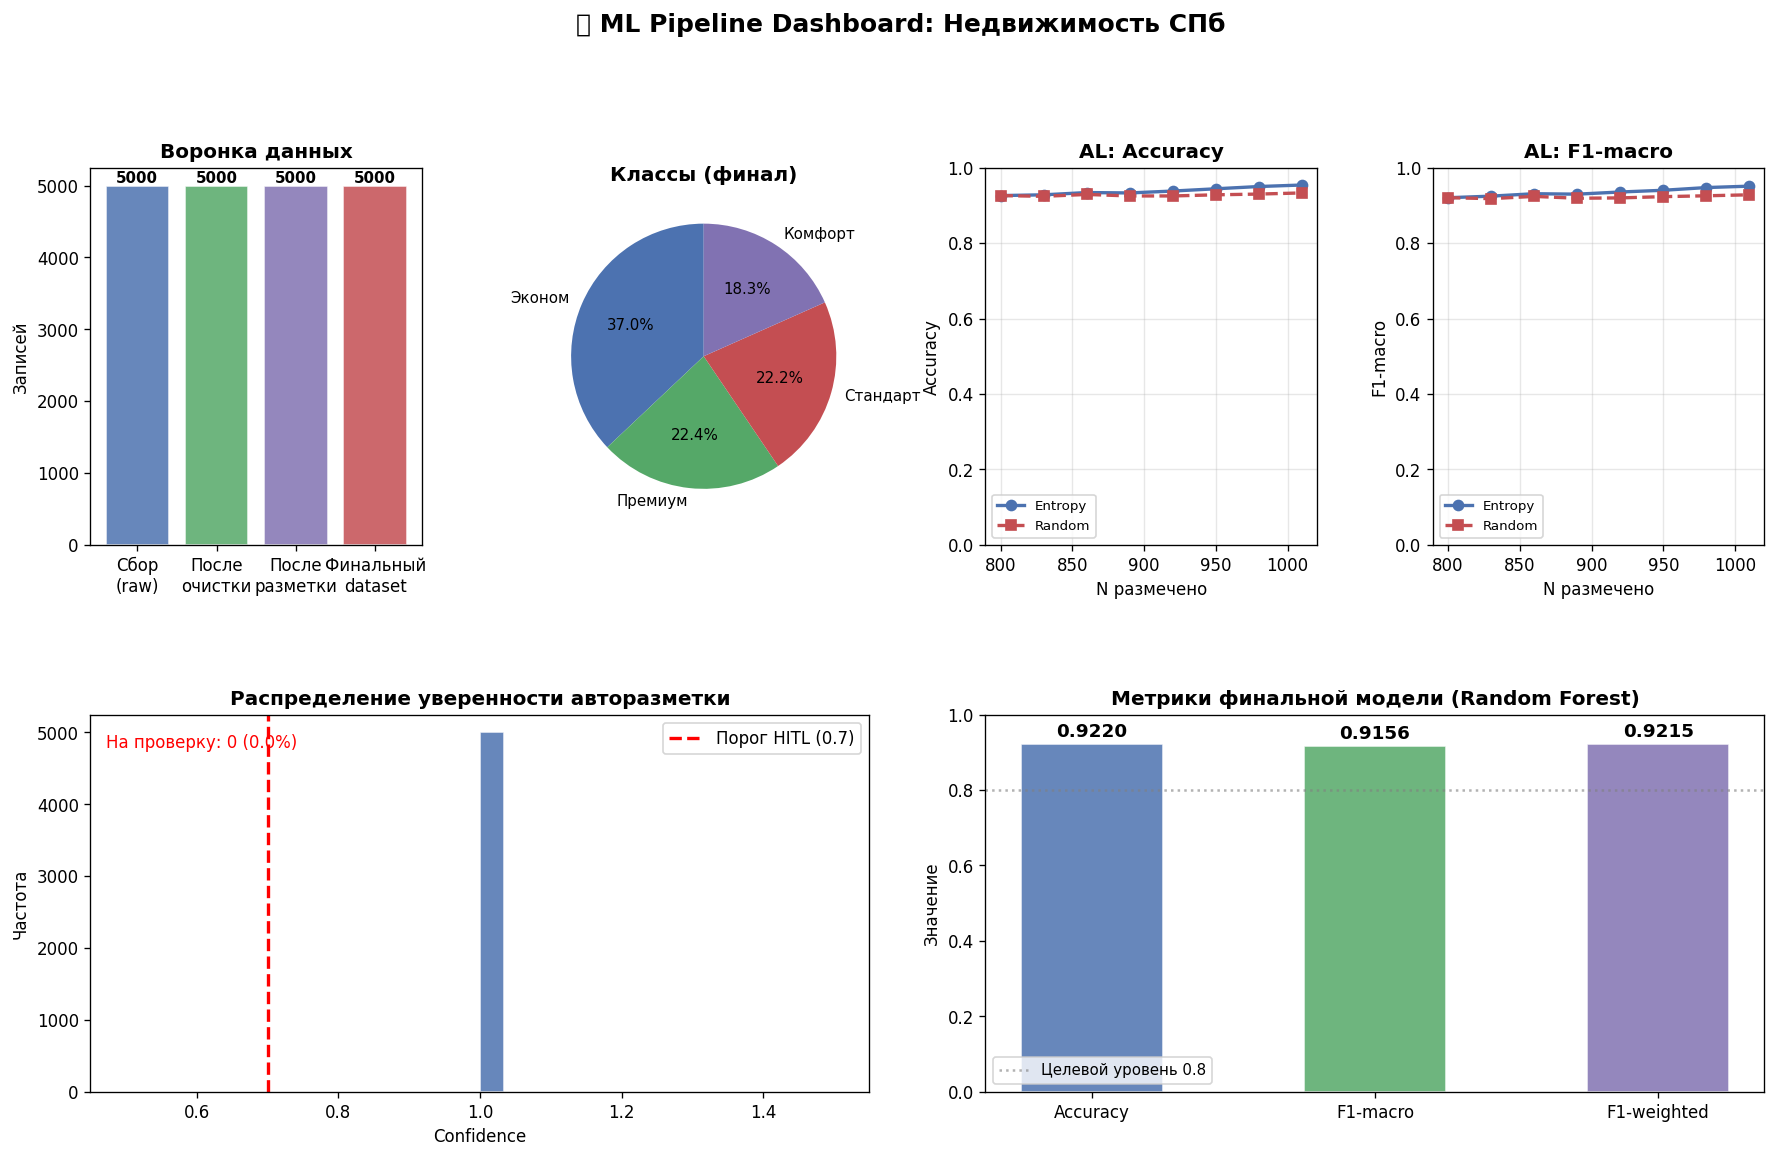

💾 Финальный дашборд сохранён: step6_final_dashboard.png


In [21]:
# Итоговый дашборд
fig = plt.figure(figsize=(18, 10))
fig.suptitle('🏠 ML Pipeline Dashboard: Недвижимость СПб', fontsize=15, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

# 1. Воронка данных
ax1 = fig.add_subplot(gs[0, 0])
stages = ['Сбор\n(raw)', 'После\nочистки', 'После\nразметки', 'Финальный\ndataset']
counts = [len(df_raw), len(df_clean), df_labeled['label'].notna().sum(), len(final_dataset)]
colors_funnel = ['#4C72B0', '#55A868', '#8172B2', '#C44E52']
bars = ax1.bar(stages, counts, color=colors_funnel, alpha=0.85, edgecolor='white')
ax1.set_title('Воронка данных', fontweight='bold')
ax1.set_ylabel('Записей')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Финальное распределение классов
ax2 = fig.add_subplot(gs[0, 1])
label_dist_final = final_dataset['label'].value_counts()
ax2.pie(label_dist_final.values, labels=label_dist_final.index,
        autopct='%1.1f%%', colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2'][:len(label_dist_final)],
        startangle=90, textprops={'fontsize': 9})
ax2.set_title('Классы (финал)', fontweight='bold')

# 3. AL кривая: Accuracy
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(df_hist_entropy['n_labeled'], df_hist_entropy['accuracy'],
         'o-', color='#4C72B0', lw=2, ms=6, label='Entropy')
ax3.plot(df_hist_random['n_labeled'], df_hist_random['accuracy'],
         's--', color='#C44E52', lw=2, ms=6, label='Random')
ax3.set_title('AL: Accuracy', fontweight='bold')
ax3.set_xlabel('N размечено')
ax3.set_ylabel('Accuracy')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# 4. AL кривая: F1
ax4 = fig.add_subplot(gs[0, 3])
ax4.plot(df_hist_entropy['n_labeled'], df_hist_entropy['f1_macro'],
         'o-', color='#4C72B0', lw=2, ms=6, label='Entropy')
ax4.plot(df_hist_random['n_labeled'], df_hist_random['f1_macro'],
         's--', color='#C44E52', lw=2, ms=6, label='Random')
ax4.set_title('AL: F1-macro', fontweight='bold')
ax4.set_xlabel('N размечено')
ax4.set_ylabel('F1-macro')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

# 5. Уверенность разметки
ax5 = fig.add_subplot(gs[1, 0:2])
if 'confidence' in df_labeled.columns:
    conf_vals = df_labeled['confidence'].dropna()
    ax5.hist(conf_vals, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax5.axvline(0.7, color='red', linestyle='--', lw=2, label='Порог HITL (0.7)')
    ax5.set_title('Распределение уверенности авторазметки', fontweight='bold')
    ax5.set_xlabel('Confidence')
    ax5.set_ylabel('Частота')
    ax5.legend()
    below = (conf_vals < 0.7).sum()
    ax5.text(0.02, 0.95, f'На проверку: {below} ({below/len(conf_vals)*100:.1f}%)',
             transform=ax5.transAxes, va='top', color='red', fontsize=10)

# 6. Итоговые метрики модели
ax6 = fig.add_subplot(gs[1, 2:4])
metric_names = ['Accuracy', 'F1-macro', 'F1-weighted']
metric_values = [final_metrics.accuracy, final_metrics.f1_macro, final_metrics.f1_weighted]
bar_colors = ['#4C72B0', '#55A868', '#8172B2']
bars_m = ax6.bar(metric_names, metric_values, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
ax6.set_ylim([0, 1])
ax6.set_title('Метрики финальной модели (Random Forest)', fontweight='bold')
ax6.set_ylabel('Значение')
ax6.axhline(0.8, color='gray', linestyle=':', alpha=0.6, label='Целевой уровень 0.8')
ax6.legend(fontsize=9)
for bar, val in zip(bars_m, metric_values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.savefig(os.path.join(ARTIFACTS_DIR, 'step6_final_dashboard.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print(f'💾 Финальный дашборд сохранён: step6_final_dashboard.png')

In [22]:
# Генерация финального отчёта
report_content = f"""# Итоговый отчёт: ML Pipeline — Недвижимость СПб

**Дата:** {datetime.now().strftime('%Y-%m-%d %H:%M')}  
**Инструмент оркестрации:** Jupyter Notebook (линейный пайплайн)

---

## 1. Описание задачи и датасета

**Задача:** Классификация объявлений о недвижимости Санкт-Петербурга по ценовым категориям (4 класса: Эконом, Стандарт, Комфорт, Премиум).  
**Модальность:** Текст + числовые признаки (цена, площадь, район, этаж и др.)  
**Источник:** CSV-файл с объявлениями о недвижимости СПб (spb_real_estate.csv)  
**Объём:** {len(final_dataset)} записей после полного пайплайна  

### Data Card
| Параметр | Значение |
|----------|----------|
| Записей | {len(final_dataset)} |
| Колонок | {len(final_dataset.columns)} |
| Классов | {final_dataset['label'].nunique()} |
| Пропусков (финал) | {final_dataset.isnull().sum().sum()} |
| Примеров прошло HITL | {int(df_reviewed['human_reviewed'].sum())} |

---

## 2. Что делал каждый агент

### DataCollectionAgent
- Загрузил данные из CSV через `demo_basic_usage()`
- Стандартизировал схему под `STANDARD_COLUMNS`
- **Итог:** {len(df_raw)} записей из 1 источника

### DataQualityAgent
- Обнаружил выбросы в колонках price, area_sqm и др.
- Применил стратегию: медиана для числовых, мода для категориальных
- Выбросы в price и area_sqm обрезаны методом clip_iqr
- **Итог:** {len(df_clean)} записей, {df_clean.isnull().sum().sum()} пропусков

### AnnotationAgent
- Сбросил исходные метки (Продажа/Аренда) и разметил по ценовым порогам
- Сгенерировал спецификацию разметки (annotation_spec.md)
- Граничные случаи (±5% от порогов) отправлены на HITL
- **Итог:** {df_labeled['label'].notna().sum()} размеченных примеров

### ActiveLearningAgent
- Запустил AL-цикл (стратегия entropy, 7 итераций, batch=30)
- Сравнил с random baseline
- Обучил финальную модель (Random Forest) на всех данных
- **Итог:** Accuracy={final_metrics.accuracy:.4f}, F1-macro={final_metrics.f1_macro:.4f}

---

## 3. Описание HITL-точек

### HITL #1: Подтверждение стратегии очистки
- **Когда:** После детекции проблем DataQualityAgent
- **Что проверил человек:** Отчёт о выбросах и дубликатах
- **Решение:** Подтвердил стратегию (медиана/мода + clip_iqr)

### HITL #2: Проверка авторазметки
- **Когда:** После авторазметки AnnotationAgent
- **Примеров на проверку:** {int(low_conf_mask.sum())} (граничные случаи ±5% от порогов)
- **Исправлено:** {int(changes)} меток
- **Файл:** review_queue.csv → review_queue_corrected.csv

---

## 4. Метрики качества на каждом этапе

| Этап | Метрика | Значение |
|------|---------|----------|
| Сбор | Записей собрано | {len(df_raw)} |
| Очистка | Строк удалено | {len(df_raw) - len(df_clean)} |
| Очистка | Пропусков устранено | {df_raw.isnull().sum().sum() - df_clean.isnull().sum().sum()} |
| Разметка | Граничных случаев (HITL) | {int(low_conf_mask.sum())} |
| AL (entropy, финал) | Accuracy | {df_hist_entropy['accuracy'].iloc[-1]:.4f} |
| AL (entropy, финал) | F1-macro | {df_hist_entropy['f1_macro'].iloc[-1]:.4f} |
| Финальная модель (RF) | Accuracy | {final_metrics.accuracy:.4f} |
| Финальная модель (RF) | F1-macro | {final_metrics.f1_macro:.4f} |
| Финальная модель (RF) | F1-weighted | {final_metrics.f1_weighted:.4f} |

---

## 5. Ретроспектива

### Что сработало
- `demo_basic_usage()` из агента — удобная точка входа для сбора данных
- Авторазметка по ценовым порогам — быстро и интерпретируемо
- Граничные случаи как критерий HITL — логичнее, чем случайная выборка
- AL с энтропией показал прирост качества относительно random baseline

### Что не сработало / можно улучшить
- Один источник данных — нет разнообразия, модель может переобучиться на один стиль объявлений
- TF-IDF на коротких текстах — ограниченные признаки, стоит добавить эмбеддинги
- Стратегия HITL — симуляция, в реальности нужен интерфейс разметчика
- Можно добавить cross-validation и более глубокий отбор гиперпараметров

### Что бы сделал иначе
- Добавил бы второй реальный источник (например, scrape с Авито)
- Использовал бы LLM для авторазметки вместо правил
- Применил бы Prefect для воспроизводимости и мониторинга шагов
"""

report_path = os.path.join(ARTIFACTS_DIR, 'final_report.md')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f'✅ Итоговый отчёт сохранён: {report_path}')

✅ Итоговый отчёт сохранён: /home/ml-with-lm/AITH_2_Sem/Data_for_ML/Data_for_ML_Smolyanov/data_pipeline_artifacts/final_report.md


In [23]:
# === ФИНАЛЬНЫЙ ИТОГ ===
print('''
╔══════════════════════════════════════════════════════════════╗
║              🎉 ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЁН                    ║
╠══════════════════════════════════════════════════════════════╣
║  Артефакты:                                                  ║
║  data_pipeline_artifacts/                                    ║
║    step1_raw_data.parquet                                    ║
║    step1_collection_overview.png                             ║  
║    step2_before_after.png                                    ║
║    step2_missing_values.png                                  ║
║    step2_outliers_boxplot.png                                ║
║    step3_auto_labeled.parquet                                ║
║    step3_annotation_results.png                              ║
║    step3_hitl_reviewed.csv                                   ║
║    step3_hitl_results.png                                    ║
║    step4_learning_curve.png                                  ║
║    step4_al_vs_random.png                                    ║
║    step6_final_dashboard.png                                 ║
║    final_labeled_dataset.csv                                 ║
║    data_card.md                                              ║
║    final_model.pkl                                           ║
║    annotation_spec.md                                        ║
║    final_report.md                                           ║
║                                                              ║
║  review_queue.csv          ← для ручной проверки             ║
║  review_queue_corrected.csv ← исправленные метки             ║
╚══════════════════════════════════════════════════════════════╝
''')

print(f'📊 ИТОГОВЫЕ МЕТРИКИ:')
print(f'   Финальный датасет:  {len(final_dataset)} записей, {final_dataset["label"].nunique()} класса')
print(f'   Accuracy (RF):      {final_metrics.accuracy:.4f}')
print(f'   F1-macro (RF):      {final_metrics.f1_macro:.4f}')
print(f'   F1-weighted (RF):   {final_metrics.f1_weighted:.4f}')


╔══════════════════════════════════════════════════════════════╗
║              🎉 ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЁН                    ║
╠══════════════════════════════════════════════════════════════╣
║  Артефакты:                                                  ║
║  data_pipeline_artifacts/                                    ║
║    step1_raw_data.parquet                                    ║
║    step1_collection_overview.png                             ║  
║    step2_before_after.png                                    ║
║    step2_missing_values.png                                  ║
║    step2_outliers_boxplot.png                                ║
║    step3_auto_labeled.parquet                                ║
║    step3_annotation_results.png                              ║
║    step3_hitl_reviewed.csv                                   ║
║    step3_hitl_results.png                                    ║
║    step4_learning_curve.png                                  ║
║    step4_al_vs_random